In [1]:
import arcgis
print(arcgis.__version__)
print(arcgis.__file__)

2.0.0
C:\Anaconda3\envs\mytestenv\lib\site-packages\arcgis\__init__.py


In [2]:
from datetime import datetime
from arcgis.features import FeatureCollection
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob

In [3]:
from arcgis.gis import GIS
from arcgis.features.analyze_patterns import calculate_density
gis = GIS("https://www.arcgis.com", "arcgis_python", "amazing_arcgis_123")
gis

GIS @ https://geosaurus.maps.arcgis.com version:9.4

In [4]:
from arcgis.features.analyze_patterns import calculate_density

In [5]:
input_item = gis.content.get('79d3e458dcaf486f81c5591a67538179')
zoning_item = gis.content.get('17339081d410464a94d2df1ddd95d3d6')
collisions = input_item.layers[0]
zoning_lyr = zoning_item.layers[0]

<Item title:"Traffic Collisions" type:Feature Layer Collection owner:Learn_ArcGIS>
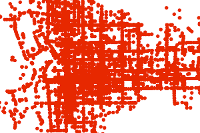

In [6]:
input_item

<Item title:"Zoning" type:Feature Layer Collection owner:CityOfPasadenaCAGIS>
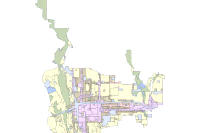

In [7]:
zoning_item

## Calculate density on point layer - Future

In [8]:
%%time
from datetime import datetime
collision_density1 = calculate_density(input_layer=collisions,
                                      output_name='density_of_incidents' + str(datetime.now().microsecond), 
                                      future=True)
collision_density1

Wall time: 35 s


<CalculateDensity GP Job: jcf198388f9444a24a1404f5b58451fd3>

In [9]:
assert isinstance(collision_density1, GPJob)
collision_density1.task

'CalculateDensity'

In [10]:
collision_density1.status

'esriJobExecuting'

In [11]:
collision_density1.messages

[]

In [12]:
%%time
item = collision_density1.result()
item

Wall time: 21 s


<Item title:"density_of_incidents400565" type:Feature Layer Collection owner:arcgis_python>

In [13]:
assert isinstance(item, Item)

In [14]:
assert item.delete()

## Calculate density - synchronous

In [15]:
%%time
from datetime import datetime
collision_density1 = calculate_density(input_layer=collisions,
                                      output_name='density_of_incidents' + str(datetime.now().microsecond))

Wall time: 32.1 s


In [16]:
assert isinstance(collision_density1, Item)
collision_density1.delete()

True

## Calculate density - Feature Collection output

In [17]:
%%time
from datetime import datetime
collision_density1b = calculate_density(input_layer=collisions)
collision_density1b

Wall time: 30.1 s


<FeatureCollection>

In [18]:
assert isinstance(collision_density1b, FeatureCollection)

In [19]:
assert isinstance(collision_density1, Item)

## Future Type checks
job1a = calculate_density(input_layer=collisions, future=True,
                                      output_name='density_of_incidents' + str(datetime.now().microsecond))
job1b = calculate_density(input_layer=collisions, future=True)
assert isinstance(job1a.result(), Item)
assert job1a.result().delete()
assert isinstance(job1b.result(), FeatureCollection)

## Calculate density within a specific polygon

In [20]:
%%time
collision_density2 = calculate_density(input_layer=collisions,
                                       radius=2,
                                       radius_units='Miles',
                                       bounding_polygon_layer=zoning_lyr,
                                       area_units='SquareMiles',
                                       classification_type='StandardDeviation',
                                       num_classes=5,
                                       output_name='density_of_incidents' + str(datetime.now().microsecond))

Wall time: 38.1 s


In [21]:
collision_density2

<Item title:"density_of_incidents868996" type:Feature Layer Collection owner:arcgis_python>

In [22]:
collision_density2.delete()

True

## Calculate density using 'context' parameter in addition to above but excluding 'output_name' parameter.

In [26]:
%%time
collision_density3 = calculate_density(input_layer=collisions,
                                       radius=2,
                                       radius_units='Miles',
                                       bounding_polygon_layer=zoning_lyr,
                                       area_units='SquareMiles',
                                       classification_type='NaturalBreaks',
                                       num_classes=10,
                                       context={"extent":{"xmin":-13152963.952528693,"ymin":4047628.887698072,"xmax":-13149830.034368917,"ymax":4049238.8426063713,"spatialReference":{"wkid":102100,"latestWkid":3857}}})

Wall time: 35.3 s


In [27]:
collision_density3

<FeatureCollection>

Apply filter on zoning layer to calculte density within a specific bounding polygon layer boundary

In [28]:
zoning_lyr.filter = "ZONE_CODE = 'PS'"

In [29]:
collision_density4 = calculate_density(input_layer=collisions,
                                       radius=2,
                                       radius_units='Miles',
                                       bounding_polygon_layer=zoning_lyr,
                                       area_units='SquareMiles',
                                       classification_type='StandardDeviation',
                                       num_classes=5,
                                       output_name='density_of_incidents' + str(datetime.now().microsecond))

In [30]:
collision_density4

<Item title:"density_of_incidents17489" type:Feature Layer Collection owner:arcgis_python>

In [31]:
collision_density4.delete()

True